In [1]:
import pandas as pd
import io
import re
import glob
import matplotlib.pyplot as plt
import os
from collections import Counter, defaultdict
from scipy.stats import chisquare
from statsmodels.stats.multitest import multipletests
import numpy as np


vcf_directory = '/Users/fionachow/Documents/NYU/CDS/Summer 2024/Human rDNA Research/Project/Human-rDNA/original reference/original_vcf_all/'
data_csv_path = '/Users/fionachow/Documents/NYU/CDS/Summer 2024/Human rDNA Research/Project/Human-rDNA/original reference/1000data.csv'

metadata_df = pd.read_csv(data_csv_path)

df5 = pd.read_csv(r'/Users/fionachow/Documents/NYU/CDS/Summer 2024/Human rDNA Research/Project/Human-rDNA/outputs/src_outputs/pg_positions.csv')

# Create a set to store pseudogene positions
pg_positions = set()
for _, row in df5.iterrows():
    pg_positions.update(range(row['Start'], row['End'] + 1))

# Create a dictionary to map Run to Population
run_to_population = dict(zip(metadata_df['Run'], metadata_df['population']))

# Calculate overall population distribution
total_population_count = metadata_df['population'].value_counts(normalize=True).to_dict()

def parse_vcf(file):
    vcf_df = pd.read_csv(file, comment='#', delimiter='\t', header=None,
                         names=['CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO'])
    # Extract the Run from the filename
    run_id = os.path.basename(file).split('_')[0]
    
    # Add population information to the VCF DataFrame
    vcf_df['population'] = run_to_population.get(run_id, 'Unknown')
    vcf_df['Run'] = run_id
    
    return vcf_df

def extract_af(info):
    match = re.search(r'AF=([\d\.]+)', info)
    return match.group(1) if match else None

def is_in_regions(pos):
    if pos in pg_positions:
        return False  # Skip pseudogene regions
    for start, end, _ in all_positions:
        if start <= pos <= end:
            return True
    return False

all_positions = [
    [1, 3656, "5'ETS"],
    [3657, 5527, '18S'],
    [5528, 6622, 'ITS1'],
    [6623, 6779, '5.8S'],
    [6780, 7934, 'ITS2'],
    [7935, 12969, '28S'],
    [12970, 13314, "3'ETS"]
]

In [2]:
# List to store data
shared_variants = {} #e.g. {'human_31_A_G': 3, 'human_33_C_G': 1, etc}

# Parse all VCF files and extract AF values
vcf_files = glob.glob(vcf_directory + '*.vcf')
for vcf_file in vcf_files:
    df = parse_vcf(vcf_file)
    df['AF'] = df['INFO'].apply(extract_af)
    df = df[df['POS'].apply(is_in_regions)]
    for _, row in df.iterrows():
        key = (row['CHROM'], row['POS'], row['REF'], row['ALT'])
        population = row['population']
        run_id = row['Run']
        if key not in shared_variants:
            shared_variants[key] = []
        shared_variants[key].append(run_id)

# Prepare data for plotting
variant_counts = [len(val) for val in shared_variants.values()]  #e.g. [3, 1,...]


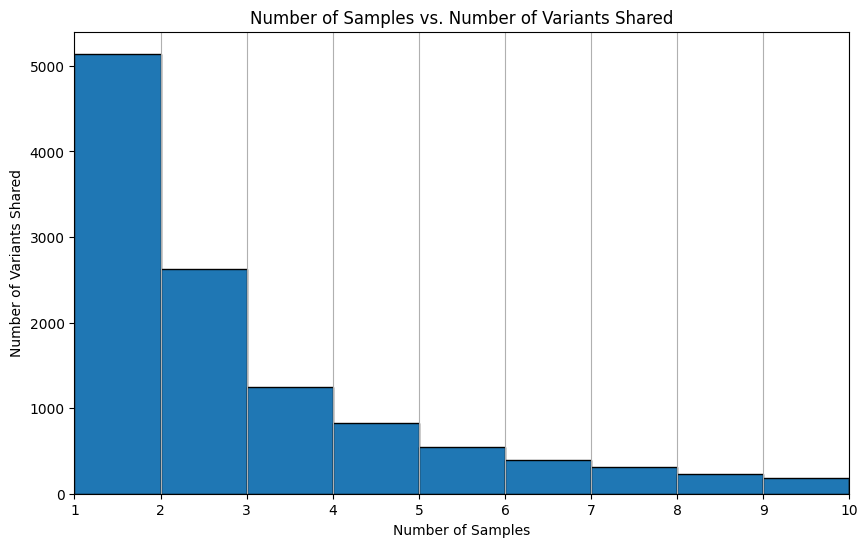

In [3]:
# Count the number of shared variants for each count of people sharing
people_sharing_counts = Counter(variant_counts) #e.g. {3: 2, 1: 1, ...} i.e. 2 counts of pple who shared 3 variants, etc

# Prepare data for plotting
x = list(people_sharing_counts.keys())
y = list(people_sharing_counts.values())

# Plotting the histogram
plt.figure(figsize=(10, 6))
plt.hist(x, bins=range(1, max(x) + 2), weights=y, edgecolor='black', orientation='vertical')
plt.xlabel('Number of Samples')
plt.ylabel('Number of Variants Shared')
plt.title('Number of Samples vs. Number of Variants Shared')
plt.xlim(1, 10)
plt.grid(axis='x')
plt.show()

In [4]:
# Filtering criteria
variant_pairs = {key: val for key, val in shared_variants.items() if len(val) == 2}

# Create a dictionary to store the count of each population for variants shared by exactly 2 people
shared_population_counts = defaultdict(int)

results = []

# Gather population counts for each variant shared by exactly 2 people
for variant, runs in variant_pairs.items():
    populations = [run_to_population[run] for run in runs]
    population_counts = Counter(populations)
    
    for pop, count in population_counts.items():
        shared_population_counts[pop] += count

In [5]:
len(total_population_count.keys()) #number of population categories is 26

26

In [125]:
#CHI-2 TEST (Goodness of Fit - one-way chi-square test) - RESCALING so observed_counts = expected_counts for chisquare function call

# Convert the dictionary to a list of observed counts
observed_counts = list(shared_population_counts.values())

# Calculate the expected counts
expected_counts = [total_population_count[pop]*(1 - total_population_count[pop]) * sum(observed_counts) for pop in shared_population_counts.keys()]

# Ensure the lengths of observed and expected counts match
if len(observed_counts) == len(expected_counts):

    # Check if sums match and adjust if necessary
    observed_sum = sum(observed_counts)
    expected_sum = sum(expected_counts)
    if observed_sum != expected_sum:
        scale_factor = observed_sum / expected_sum
        expected_counts = [count * scale_factor for count in expected_counts]

    print(f"Observed counts: {shared_population_counts}")
    print(f"Expected counts: {expected_counts}")
    print(scale_factor)

    # Perform chi-square test using chisquare function
    k = len(expected_counts)  # Number of categories
    chi2_statistic, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts, ddof=0)

    results.append(("Overall", p_value))

    # Calculate Cramér's V
    n = sum(observed_counts)  # Total sample size
    cramers_v = np.sqrt(chi2_statistic / (n * (k - 1)))
    print(f"Cramér's V: {cramers_v}")
    print(n, k)


Observed counts: defaultdict(<class 'int'>, {'YRI': 270, 'MSL': 138, 'MXL': 163, 'GBR': 96, 'CLM': 195, 'LWK': 182, 'BEB': 257, 'CHB': 159, 'ESN': 217, 'CEU': 327, 'GWD': 368, 'PEL': 235, 'IBS': 301, 'ITU': 136, 'CHS': 357, 'TSI': 157, 'PJL': 281, 'STU': 180, 'ACB': 195, 'GIH': 147, 'ASW': 118, 'KHV': 266, 'PUR': 211, 'FIN': 118, 'CDX': 136, 'JPT': 144})
Expected counts: [292.9845243943302, 167.20908191465483, 163.93671597204826, 154.09349147003618, 220.57444686990667, 167.20908191465483, 218.97473238133037, 173.74075046277167, 247.60303562772663, 294.53307414594633, 292.9845243943302, 204.52831447003285, 260.2135103712909, 180.2550012280936, 269.62564474912733, 180.2550012280936, 242.85614551038267, 191.61302852755645, 194.84838168172368, 173.74075046277167, 125.99153184747564, 204.52831447003285, 231.74196717004946, 167.20908191465483, 157.3789207497389, 175.3709460712392]
1.0423346628191823
Cramér's V: 0.03618612576301699
5354 26


In [130]:
#CHI-2 TEST (Goodness of Fit - one-way chi-square test) Normalizing expected_counts so observed_counts = expected_counts for chisquare function call

# Observed counts for each population type
observed_counts = list(shared_population_counts.values())

# Expected counts for each population type
initial_expected_counts = [total_population_count[pop] * (1 - total_population_count[pop]) * sum(observed_counts) for pop in shared_population_counts.keys()]

# Normalize the initial expected counts to get proportions
total_initial_expected = sum(initial_expected_counts)
normalized_expected_counts = [count / total_initial_expected for count in initial_expected_counts]

# Scale normalized counts to match the sum of observed_counts
expected_counts = [count * sum(observed_counts) for count in normalized_expected_counts]

# Print for verification
print(f'Observed counts: {observed_counts}')
print(f'Normalized expected counts (as proportions): {normalized_expected_counts}')
print(f'Scaled expected counts: {expected_counts}')
print(f'Sum of observed counts: {sum(observed_counts)}')
print(f'Sum of expected counts: {sum(expected_counts)}')

# Perform chi-square goodness-of-fit test
chi2_statistic, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts, ddof=0)

# Calculate Cramér's V
n = sum(observed_counts)  # Total sample size
k = len(expected_counts)  # Number of categories (population types)
cramers_v = np.sqrt(chi2_statistic / (n * (k - 1)))

print(f"Chi-square statistic: {chi2_statistic}")
print(f"P-value: {p_value}")
print(f"Cramér's V: {cramers_v}")

# Apply Bonferroni correction if multiple tests were done
if results:
    variants, p_values = zip(*results)
    _, corrected_p_values, _, _ = multipletests(p_values, method='bonferroni')

    results_df = pd.DataFrame({'Variant': variants, 'P-Value': p_values, 'Bonferroni': corrected_p_values})

    significant_results = results_df[results_df['Bonferroni'] < 0.05]

    results_df.to_csv('chi_square_results.csv', index=False)



Observed counts: [270, 138, 163, 96, 195, 182, 257, 159, 217, 327, 368, 235, 301, 136, 357, 157, 281, 180, 195, 147, 118, 266, 211, 118, 136, 144]
Normalized expected counts (as proportions): [0.054722548448698206, 0.031230683958657978, 0.030619483745246215, 0.0287810032629877, 0.041198066281267584, 0.031230683958657978, 0.040899277620719154, 0.032450644464469866, 0.04624636451769268, 0.05501178075195112, 0.054722548448698206, 0.038201029971989695, 0.0486017016009135, 0.03366735174226626, 0.05035966468978844, 0.03366735174226626, 0.04535975822009389, 0.035788761398497654, 0.03639304850237648, 0.032450644464469866, 0.023532224850107513, 0.038201029971989695, 0.04328389375607947, 0.031230683958657978, 0.029394643397411074, 0.03275512627404542]
Scaled expected counts: [292.9845243943302, 167.2090819146548, 163.93671597204823, 154.09349147003616, 220.57444686990664, 167.2090819146548, 218.97473238133034, 173.74075046277167, 247.6030356277266, 294.53307414594633, 292.9845243943302, 204.5283

In [6]:
og_ref_file = '/Users/fionachow/Documents/NYU/CDS/Summer 2024/Human rDNA Research/Project/Human-rDNA/outputs/src_outputs/og_ref.csv'

# Load the original reference file
og_ref_df = pd.read_csv(og_ref_file)

# Prepare data for each segment
segment_data = {label: {'A': 0, 'T': 0, 'C': 0, 'G': 0} for _, _, label in all_positions}

# Count the total number of each base (A, T, C, G) for each segment
for pos in range(1, 13315):
    if pos in pg_positions:  # Skip pseudogene positions
        continue
    base = og_ref_df.loc[og_ref_df['POS'] == pos, 'REF'].values[0]
    for start, end, label in all_positions:
        if start <= pos <= end:
            segment_data[label][base] += 1

# Calculate overall GC content
total_counts = {'A': 0, 'T': 0, 'C': 0, 'G': 0}
for base in total_counts:
    total_counts[base] = sum(segment_data[label][base] for label in segment_data)

total_gc_count = total_counts['G'] + total_counts['C']
total_at_count = total_counts['A'] + total_counts['T']
total_gc_content = total_gc_count / (total_gc_count + total_at_count)

# Calculate observed GC content for 3'ETS
ets_gc_count = segment_data["3'ETS"]['G'] + segment_data["3'ETS"]['C']
ets_at_count = segment_data["3'ETS"]['A'] + segment_data["3'ETS"]['T']
ets_total_count = ets_gc_count + ets_at_count
ets_gc_content = ets_gc_count / ets_total_count

# Expected counts based on overall GC content
expected_gc_count = ets_total_count * total_gc_content
expected_at_count = ets_total_count * (1 - total_gc_content)

# Chi-square goodness of fit test
observed = [ets_gc_count, ets_at_count]
expected = [expected_gc_count, expected_at_count]
chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

# Output the results
print(f"3'ETS GC Content: {ets_gc_content:.4f}")
print(f"Overall GC Content: {total_gc_content:.4f}")
print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("The difference in GC content in the 3'ETS segment is statistically significant.")
else:
    print("The difference in GC content in the 3'ETS segment is not statistically significant.")


3'ETS GC Content: 0.8290
Overall GC Content: 0.7310
Chi-square statistic: 16.8597
P-value: 4.0247452089716875e-05
The difference in GC content in the 3'ETS segment is statistically significant.
